<!-- reader-content -->

# What happens during a qubit measurement?

A qubit starts in $|+\rangle=(|0\rangle+|1\rangle)/\sqrt{2}$. As we monitor
$\sigma_z$, some trajectories approach a pole quickly; others wander or reverse
direction before settling. Generate these individual histories and the density
of an entire ensemble from the same dispersive-readout model.

[Murch et al. (2013)](https://doi.org/10.1038/nature12539) tracked conditional
superconducting-qubit states and checked them with tomography on repeated
preparations. Here we simulate ideal detection and no intrinsic qubit decay.
The figures illustrate that measurement dynamics; they do not fit the experiment's
finite-efficiency data or perform an experimental tomography validation.

## Set the measurement strength from the resonator

The resonator has a 20 MHz linewidth and a full conditional frequency pull of
$-4$ MHz. Drive halfway between its two conditional resonances, then compare
the settled fields for the qubit in $|0\rangle$ and $|1\rangle$.

In [1]:
import numpy as np
from quchip import (
    RWA, ChargeDrive, Chip, CrossKerr, DuffingTransmon,
    QuantumSequence, Resonator, Square,
)

amplitude = 0.008                       # GHz
kappa = 2 * np.pi * 0.020              # 1/ns
q = DuffingTransmon(freq=5.0, anharmonicity=-0.25, levels=2, label="q")
r = Resonator(freq=6.0, levels=12, T1=1 / kappa, label="r")
readout = Chip(
    [q, r], couplings=[CrossKerr(q, r, chi=-0.004, label="qr")],
    frame={"q": 5.0, "r": 5.998}, approximation=RWA(),
)
drive = ChargeDrive(r, label="readout")
_ = readout.wire(drive)
sequence = QuantumSequence(readout)
_ = sequence.schedule(
    drive, envelope=Square(duration=400.0, amplitude=amplitude), freq=5.998,
)
branches = sequence.simulate_batch(
    sequence.vary("initial_state", [{"q": 0, "r": 0}, {"q": 1, "r": 0}]),
    tlist=np.arange(401.0), e_ops=readout.e_ops(r=["a", "n"]),
    states="none", progress=False,
)
alpha = np.array([branch.expect(r, 0)[-1] for branch in branches])
nbar = float(branches[1].expect(r, 1)[-1].real)
gamma = float(kappa * abs(alpha[0] - alpha[1]) ** 2 / 2)
print(f"Measurement dephasing: {gamma:.8f} /ns; steady photons: {nbar:.6f}")

Measurement dephasing: 0.00148714 /ns; steady photons: 0.153846


We use the steady-field reduction
$\Gamma_m=\kappa|\alpha_0-\alpha_1|^2/2$, represented by
$L=\sqrt{\Gamma_m/2}\,\sigma_z$. Then
$\mathcal D[L]\rho=(\Gamma_m/2)(\sigma_z\rho\sigma_z-\rho)$ and the
unconditional coherence decays as $e^{-\Gamma_m t}$.
Here `gamma` means $\Gamma_m$, in $\mathrm{ns}^{-1}$.
The cavity settles on a scale $2/\kappa\approx16$ ns, much shorter than
$1/\Gamma_m$. The reduced model starts with the field already settled and tracks
out the deterministic Stark rotation. It omits the initial cavity transient.

## Monitor the qubit

Declare the effective channel with the public model-extension interface. Its
Hamiltonian is zero in the tracked frame. We prepare the bare superposition
because $x,y,z$ refer to the declared Pauli basis, rather than a dressed
eigenvector convention for a degenerate Hamiltonian.

In [2]:
from quchip import CollapseChannel, with_monitoring
from quchip.declarative import DeviceModel, parameter

class MeasuredQubit(DeviceModel):
    gamma: float = parameter(nonnegative=True, unit="1/ns")

    def local_hamiltonian(self, op, p):
        return 0.0 * op.n

    def dissipation(self, op, p):
        return (CollapseChannel(op.sigma_z, p.gamma / 2, "z"),)

meter = MeasuredQubit(gamma=gamma, levels=2, label="q")
chip = Chip([meter], backend="qutip", frame="lab")
plus = (chip.bare_state({meter: 0}) + chip.bare_state({meter: 1})) / np.sqrt(2)
t = np.arange(0.0, 1000.0 + 5.0, 5.0)  # saved samples in ns
shots, seed = 6769, 11
problem = QuantumSequence(chip).build_problem(
    t, initial_state=plus, solver="smesolve", states="none",
    e_ops=chip.e_ops(q=[meter.sigma_x, meter.sigma_y, meter.sigma_z]),
    run_args={"ntraj": shots, "seeds": seed},
    options={"method": "platen", "dt": 0.05,
             "keep_runs_results": True, "progress_bar": ""},
)
channel = problem.engine_result.slh.channels[0]
result = chip.solve(with_monitoring(problem, {channel.key: 1.0}))
bloch = np.empty((shots, len(t), 3))
for i in range(shots):
    trajectory = result.run(i)
    bloch[i] = np.column_stack([trajectory.expect(meter, k).real for k in range(3)])
print(f"Bloch data: {bloch.shape}; final |z| > 0.95: {np.mean(abs(bloch[:, -1, 2]) > 0.95):.3f}")

Bloch data: (6769, 201, 3); final |z| > 0.95: 0.757


The array axes are `(shot, saved time, x/y/z)`. States are not retained because
these three observables contain the qubit information used here. `dt=0.05` ns
sets the native integration step; the 5 ns save interval only sets the plot
sampling. QuTiP owns the stochastic integration and seeded trajectories.
Reduce `shots` for a quick preview; rare reversals are easier to find in the
full ensemble.

## Compare individual histories

Each row below selects five paths ending near each pole. The selections expose
different histories within the same ensemble; they are neither disjoint classes
nor estimates of their prevalence. “Early return” means a path approached its
eventual pole, then moved away. “Reversal” means it first approached the opposite
pole. No external kick or relaxation is applied: a state near an eigenstate can
reverse, while an exact $\sigma_z$ eigenstate is stationary under this measurement.

<details>
<summary>Select and plot the histories</summary>

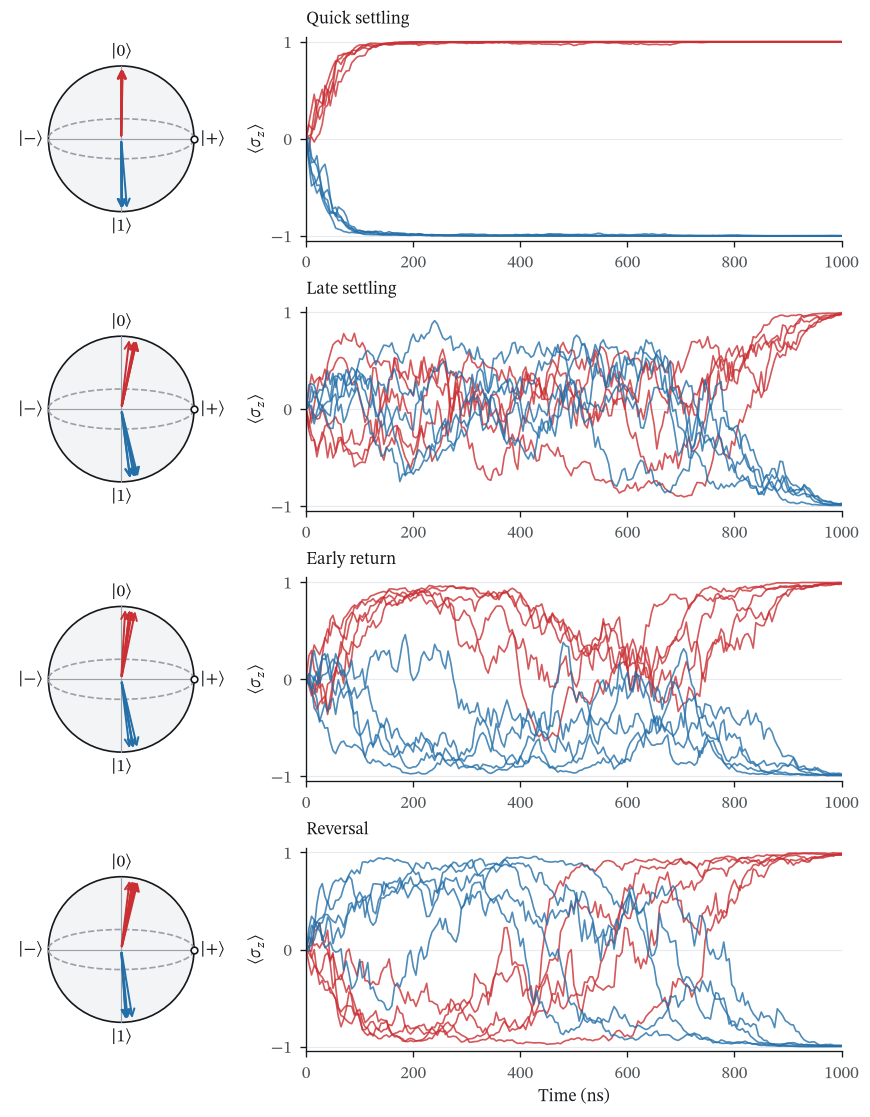

In [3]:
import shutil
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle

plt.style.use("../docs/_static/quchip.mplstyle")
plt.rcParams["text.usetex"] = bool(shutil.which("latex"))
z = bloch[:, :, 2]
selected = {}
for kind in ("Quick settling", "Late settling", "Early return", "Reversal"):
    selected[kind] = []
    for sign in (1, -1):
        toward = sign * z
        candidates = np.flatnonzero(toward[:, -1] > 0.97)
        if kind == "Quick settling":
            last_outside = np.max(np.where(toward <= 0.95, np.arange(len(t)), -1), axis=1)
            score = -t[np.minimum(last_outside + 1, len(t) - 1)]
        elif kind == "Reversal":
            score = (-toward).max(axis=1)
        else:
            after = t >= (400.0 if kind == "Early return" else 250.0)
            if kind == "Early return":
                early = np.any(toward[:, t <= 400.0] > 0.9, axis=1)
                candidates = candidates[early[candidates]]
            score = abs(np.diff(toward[:, after], axis=1)).sum(axis=1) + 4 * (1 - toward[:, after]).mean(axis=1)
        selected[kind].extend(candidates[np.argsort(-score[candidates])[:5]])

fig, axes = plt.subplots(4, 2, figsize=(7.2, 9.2), width_ratios=(1, 2.3), layout="constrained")
for (kind, indices), (sphere, trace) in zip(selected.items(), axes):
    sphere.add_patch(Circle((0, 0), 1, facecolor="#F2F4F6", edgecolor="#16181C"))
    sphere.add_patch(Arc((0, 0), 2, 0.55, color="#9AA0A8", linestyle="--"))
    sphere.plot([-1, 1], [0, 0], color="#9AA0A8", lw=0.7)
    sphere.plot([0, 0], [-1, 1], color="#9AA0A8", lw=0.7)
    for i in indices:
        color = "#C92F33" if z[i, -1] > 0 else "#246FA8"
        sphere.annotate("", xy=bloch[i, -1, [0, 2]], xytext=(0, 0),
                        arrowprops={"arrowstyle": "->", "color": color, "lw": 1.2})
        trace.plot(t, z[i], color=color, lw=1.0, alpha=0.8)
    for x, y, label in ((0, 1.2, r"$|0\rangle$"), (0, -1.2, r"$|1\rangle$"),
                         (1.25, 0, r"$|+\rangle$"), (-1.25, 0, r"$|-\rangle$")):
        sphere.text(x, y, label, ha="center", va="center")
    sphere.scatter([1], [0], s=16, facecolor="white", edgecolor="#16181C", zorder=5)
    sphere.set(xlim=(-1.5, 1.5), ylim=(-1.4, 1.4), aspect="equal")
    sphere.axis("off")
    trace.set(title=kind, xlim=(0, t[-1]), ylim=(-1.05, 1.05), yticks=(-1, 0, 1),
              ylabel=r"$\langle\sigma_z\rangle$")
axes[-1, 1].set_xlabel("Time (ns)")
fig.savefig("../docs/images/measurement_histories.svg")
plt.show()

</details>

```{figure} ../images/measurement_histories.svg
:alt: Four sets of ten conditional qubit trajectories, with final Bloch vectors and histories of sigma z.

All paths start at $+x$. Red and blue indicate the final pole, including before
the outcome becomes apparent. The left panels show the final Bloch vectors.
[PDF](../images/measurement_histories.pdf)
```

## Map the ensemble and a selected endpoint

[Weber et al. (2014)](https://doi.org/10.1038/nature13559) studied density maps
and most-likely paths with both initial and final states specified. For their
no-drive case and ideal efficiency, the analytic path from $z(0)=0$ to $z(T)=z_f$
is $z_\mathrm{opt}(t)=\tanh[(t/T)\operatorname{arctanh}(z_f)]$ and
$x_\mathrm{opt}(t)=\sqrt{1-z_\mathrm{opt}(t)^2}$.
The paper's measurement time is $\tau=1/(2\Gamma_m)$ in our convention.

Select $z(1000\,\mathrm{ns})=0.8\pm0.03$ from the already generated ensemble.
The dashed curve is the analytic most-likely path. The solid curve is the mean
of the selected paths, a different statistic. No optimizer or additional solve
is needed for this no-drive result.

In [4]:
target, window = 0.8, 0.03
conditioned = abs(z[:, -1] - target) < window
optimal = np.tanh(t / t[-1] * np.arctanh(target))
print(f"Endpoint-selected shots: {conditioned.sum()} of {shots}")

Endpoint-selected shots: 89 of 6769


<details>
<summary>Plot the two density maps</summary>

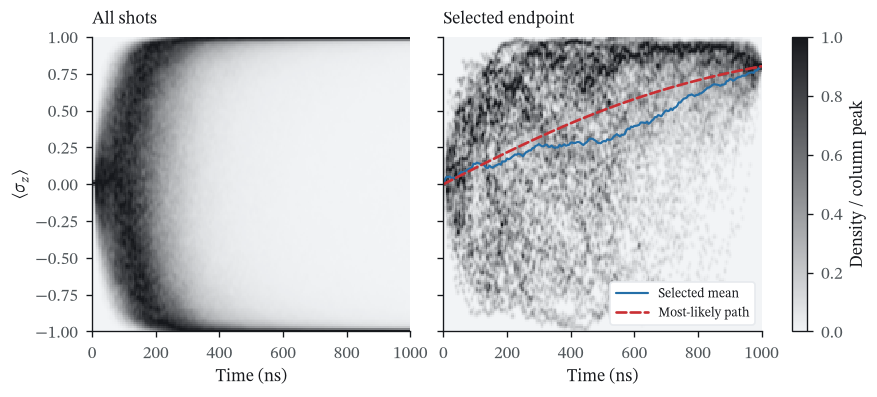

In [5]:
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter

edges = np.linspace(-1, 1, 161)
cmap = LinearSegmentedColormap.from_list("measurement", ["#F2F4F6", "#16181C"])
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), sharey=True, layout="constrained")
for axis, paths, title in zip(axes, (z, z[conditioned]), ("All shots", "Selected endpoint")):
    counts = np.stack([np.histogram(paths[:, j], bins=edges)[0] for j in range(len(t))], axis=1)
    density = gaussian_filter(counts.astype(float), sigma=(1.0, 0.7), mode="nearest")
    density /= density.max(axis=0, keepdims=True)
    image = axis.imshow(density, origin="lower", aspect="auto", cmap=cmap, vmin=0, vmax=1,
                        extent=(-2.5, t[-1] + 2.5, -1, 1), interpolation="nearest")
    axis.set(title=title, xlabel="Time (ns)", xlim=(0, t[-1]), ylim=(-1, 1))
    axis.grid(False)
axes[0].set_ylabel(r"$\langle\sigma_z\rangle$")
axes[1].plot(t, z[conditioned].mean(axis=0), color="#246FA8", lw=1.3, label="Selected mean")
axes[1].plot(t, optimal, color="#C92F33", ls="--", lw=1.6, label="Most-likely path")
axes[1].legend(loc="lower right", fontsize=8, frameon=True, framealpha=1,
               facecolor="#FFFFFF", edgecolor="#E7EAEE")
fig.colorbar(image, ax=axes, label="Density / column peak", fraction=0.035, pad=0.02)
fig.savefig("../docs/images/measurement_density.svg")
plt.show()

</details>

```{figure} ../images/measurement_density.svg
:alt: The density of all simulated trajectories splits toward the poles; an endpoint-selected density is compared with its mean and analytic most-likely path.

Each time column is smoothed and divided by its own maximum, as a display of
where paths concentrate. Shades cannot compare absolute probabilities between
columns or panels. The endpoint window gives a finite subensemble around the
analytic path's exact boundary condition.
[PDF](../images/measurement_density.pdf)
```

## Check the ensemble and save the data

Discarding the measurement record gives $\langle x\rangle=e^{-\Gamma_m t}$
and $\langle z\rangle=0$. The final excited and ground populations average to
one half. For observables bounded by $[-1,1]$, $1/\sqrt{N}$ bounds the standard
error at any one time. Report the largest discrepancy alongside that scale;
refine the integration timestep when studying finer trajectory features.

In [6]:
mean = bloch.mean(axis=0)
print(f"Max ensemble errors: x={abs(mean[:, 0] - np.exp(-gamma * t)).max():.4f}, "
      f"z={abs(mean[:, 2]).max():.4f}; single-time error bound={1 / np.sqrt(shots):.4f}")
print(f"Max Bloch-radius error: {abs(np.linalg.norm(bloch, axis=-1) - 1).max():.2e}")
np.savez_compressed(
    "paths-plus-z.npz", bloch=bloch.astype(np.float32), t=t,
    gamma=gamma, nbar=nbar, amp=amplitude,
)

Max ensemble errors: x=0.0053, z=0.0115; single-time error bound=0.0122
Max Bloch-radius error: 6.03e-04


`paths-plus-z.npz` contains the `(shot, time, 3)` Bloch array and the time,
measurement-rate, photon-number and drive-amplitude values. The fixed seed and
native method make reruns reproducible within the same QuTiP version.

For the experimental reconstruction and the path equations, see
[Murch et al., Nature 502, 211 (2013)](https://arxiv.org/abs/1305.7270) and
[Weber et al., Nature 511, 570 (2014)](https://arxiv.org/abs/1403.4992).